# NIFH DIAZATROPS DATA SET FORMATTING (DEPTH INTEGRATED)
This notebook aims to explore and analyze the data from the 2 datasets with focus on the nifh gene data sheet in .xls file.

In [108]:
import sys
print(sys.executable)

/home/tim/OneDrive/fedora/Documents/SEMESTER4/int/werkstudent/N2-fixers-in-the-ocean/.venv/bin/python


In [109]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib

There are some files that need to be present for this notebook to work:
- ***./csv/DiazotrophsDatabase-20240109_depth_int.csv***
- ***./csv/MAREDAT_diazotroph_nifh.csv_depth_int***
- ***./csv/Tang_GeophysicalResLett_2019_Data_depth_intcsv***

Each takes the data from the nifh gene depth integrated sheet of the corresponding exel file that I export as a csv file in order to be processed using pandas.

There are some simple functions we would like to use for both datasets that I also used in another notebook. And since they are useful and can and should be used here I put them into a separate file from where they are imported.

In [110]:
# Python does not allow to have .. in the path name for modules so this makes it possible

import sys
import os

sys.path.append(os.path.abspath(".."))

In [111]:
from new_approach.format import removeEmptyRows, removeRed, objToNum, filterDepth, roundCoord, setND

Since we want to plot the csv data as a scatter plot on the globe quite frequently I thought it would be useful to separate that functionality into a new functiion and generally such functions go into a file. 

In [112]:
from new_approach.visualize import plotColsOnMap
from new_approach.parula_diy import parula_map

There is a list of columns we actually want to keep in the final set in order to predict them. Other columns are not needed for this project and can be removed.

In [113]:
keepers = ['LATITUDE', 'LONGITUDE', 'DEPTH (m)','Trichodesmium nifH Gene (x106 copies m-2)', 'Total UCYN-A nifH Gene (x106 copies m-2)','UCYN-B nifH Gene (x106 copies m-2)',"UCYN-A nifH Gene (x106 copies m-2)"]
coord = ['LATITUDE', 'LONGITUDE']

# First dataset
This dataset is from the paper [Global oceanic diazotroph database version 2 and
elevated estimate of global oceanic N2 fixation](https://essd.copernicus.org/articles/15/3673/2023/essd-15-3673-2023-assets.html). (Luo)

In [114]:
#we want to remember which columns here to show
dzdb_cols = ['Trichodesmium nifH Gene (x106 copies m-2)', 'UCYN-A nifH Gene (x106 copies m-2)','UCYN-B nifH Gene (x106 copies m-2)']

#the dataset is opened
dzdb_2024_nifh = pd.read_csv("../csv/nifh_di/DiazotrophsDatabase-20240109_depth_int.csv")
print(dzdb_2024_nifh.info())
dzdb_2024_nifh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688 entries, 0 to 687
Data columns (total 25 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   SOURCE: Related article or authors                         73 non-null     object 
 1   METHODS:                  Sampling/Analysis                688 non-null    object 
 2   DATE (yyyy-mm-dd)                                          688 non-null    object 
 3   LATITUDE                                                   688 non-null    float64
 4   LONGITUDE                                                  688 non-null    float64
 5   DEPTH (m)                                                  688 non-null    object 
 6   Trichodesmium nifH Gene (x106 copies m-2)                  613 non-null    object 
 7   UCYN-A1 nifH Gene (x106 copies m-2)                        214 non-null    object 
 8   UCYN-A2 ni

,SOURCE: Related article or authors,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-2),UCYN-A1 nifH Gene (x106 copies m-2),UCYN-A2 nifH Gene (x106 copies m-2),UCYN-A nifH Gene (x106 copies m-2),...,Richelia (het-2 or ReuHH01) nifH Gene (x106 copies m-3),Richelia ( RrhiSC01) nifH Gene (x106 copies m-3),Calothrix nifH Gene (x106 copies m-2),Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),Fe (nM),Chlorophyll (mg m-3),Notes
0,"Church et al. (2005a), doi:10.3354/ame038003",qPCR,12/14/2002,22.75,-158.0,200.00,271.12,NaN,NaN,11028.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Trichodesmium integrated down to 100 m depth
1,"Church et al. (2005b), doi:10.1128/Aem.71.9.53...",qPCR,12/13/2002,22.75,-158.0,175.00,462.78,NaN,NaN,3678.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,midnight sample
2,NaN,qPCR,12/14/2002,22.75,-158.0,150.00,4861.12,NaN,NaN,14646.35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,noon sample
3,"Fong et al. (2008), doi:10.1038/ismej.2008.22",qPCR,7/16/2005,22.75,-158.0,100.00,18000.00,NaN,NaN,6400.00,...,NaN,NaN,320.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,qPCR,7/26/2005,22.37,-157.5,100.00,17000.00,NaN,NaN,5800.00,...,NaN,NaN,810.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
setND(dzdb_2024_nifh, dzdb_cols)

#I removed all redundant columns and made everything into a number
removeRed(coord+dzdb_cols, dzdb_2024_nifh)
objToNum(dzdb_2024_nifh)

dzdb_2024_nifh_df = dzdb_2024_nifh
# a lot of empty rows are actually no data that corresponds to 0, so they should not be dropped
# However i am concerned that I am imputing not only n.d but also NaN this might need adressing
dzdb_2024_nifh_df = removeEmptyRows(dzdb_cols,dzdb_2024_nifh_df)

#coordinates are rounded
dzdb_2024_nifh_rnd = roundCoord(cols=dzdb_cols, df=dzdb_2024_nifh_df)

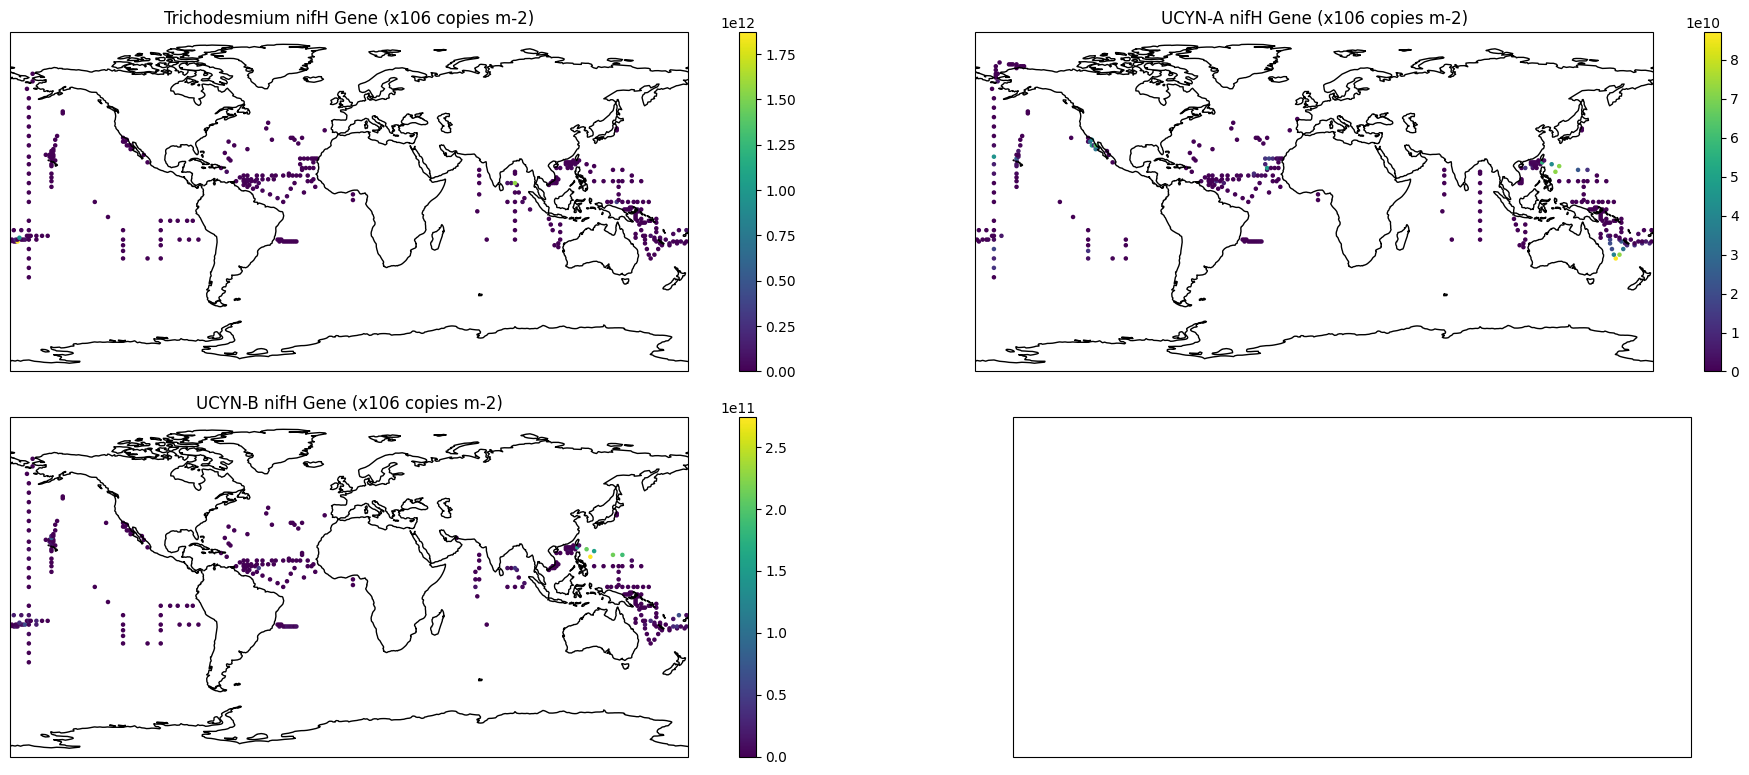

In [116]:
#we also want to plot the contents of the dataset on the map, which we can do now as all data is numeric
plotColsOnMap(dzdb_cols, dzdb_2024_nifh_rnd)

As a result we got a significantly smaller number of entries, which is especially seen with the data columns. But now we only have the data we actually want and need.

In [117]:
dzdb_2024_nifh_rnd.describe()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-2),UCYN-A nifH Gene (x106 copies m-2),UCYN-B nifH Gene (x106 copies m-2)
count,653.000000,653.000000,6.130000e+02,552.000000,565.000000
mean,13.467075,-34.591118,2.121517e+04,9704.626685,7627.101027
std,21.324780,127.335096,2.038751e+05,23014.887473,37324.263031
min,-40.000000,-180.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,-158.000000,1.325000e+01,2.292500,0.080000
50%,20.000000,-56.000000,3.300900e+02,391.245000,123.360000
75%,23.000000,110.000000,2.663030e+03,7538.260000,1807.120000
max,74.000000,179.000000,3.525556e+06,217865.370000,607258.350000


In [118]:
dzdb_2024_nifh_rnd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 653 entries, 0 to 687
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   653 non-null    int64  
 1   LONGITUDE                                  653 non-null    int64  
 2   Trichodesmium nifH Gene (x106 copies m-2)  613 non-null    float64
 3   UCYN-A nifH Gene (x106 copies m-2)         552 non-null    float64
 4   UCYN-B nifH Gene (x106 copies m-2)         565 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 30.6 KB


# Second dataset
This is the dataset from the  [Database of diazotrophs in global ocean: abundance, biomass and nitrogen fixation rates](https://doi.pangaea.de/10.1594/PANGAEA.774851)

In [119]:
maredat_cols =['Trichodesmium nifH Gene (x106 copies m-2)','UCYN-B nifH Gene (x106 copies m-2)',"UCYN-A nifH Gene (x106 copies m-2)"]

#here we open the dataset of the other database for cell count
maredat_nifh = pd.read_csv("../csv/nifh_di/MAREDAT_diazotroph_depth_int.csv")
print(maredat_nifh.info())
maredat_nifh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 33 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    88 non-null     object 
 1   SOURCE: Related article                                         105 non-null    object 
 2   METHODS:                  Sampling/Analysis                     109 non-null    object 
 3   DATE (yyyy-mm-dd)                                               109 non-null    object 
 4   LATITUDE                                                        109 non-null    float64
 5   LONGITUDE                                                       109 non-null    float64
 6   DEPTH (m)                                                       109 non-null    int64  
 7   Trichodesmium nifH Gene (x106 copies m-2)            

,SOURCE: Data,SOURCE: Related article,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-2),Trichodesmium Biomass Conversion factor (mg C/106 nifH copies),Trichodesmium Biomass (mg C m-2),...,Heterocyst (Richelia & Calotrhix) Biomass (mg C m-2),Total Diazotrophic Biomass (mg C m-2),Surface Temperature (˚C),Surface Salinity (PSU),Surface Nitrate (µM),Surface Phosphate (µM),Surface Fe (nM),Chlorophyll (mg m-2),Notes,Proteobacteria nifH Gene (x106 copies/m2)
0,NaN,"Church et al. (2005a), doi:10.3354/ame038003",qPCR,2002-12-14,22.75,-158.0,200,271.1200,0.3,81.33,...,NaN,87.720,NaN,NaN,NaN,NaN,NaN,NaN,Trichodesmium integrated down to 100 m depth,NaN
1,NaN,"Church et al. (2005b), doi:10.1128/Aem.71.9.53...",qPCR,2002-12-13,22.75,-158.0,175,462.7817,0.3,138.83,...,5.0905,809.414,NaN,NaN,NaN,NaN,NaN,NaN,midnight sample,NaN
2,NaN,"Church et al. (2005b), doi:10.1128/Aem.71.9.53...",qPCR,2002-12-14,22.75,-158.0,150,4861.1240,0.3,1458.34,...,111.9378,1573.320,NaN,NaN,NaN,NaN,NaN,NaN,noon sample,NaN
3,NaN,"Fong et al. (2008), doi:10.1038/ismej.2008.22",qPCR,2005-07-16,22.75,-158.0,100,18000.0000,0.3,5400.00,...,71.3000,5477.780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,"Fong et al. (2008), doi:10.1038/ismej.2008.22",qPCR,2005-07-26,22.37,-157.5,100,17000.0000,0.3,5100.00,...,4313.3000,9460.460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2900.0


In [120]:
#no data is converted into a 0 
setND(maredat_nifh, maredat_cols)
#I removed all redundant columns and made everything into a number
removeRed(coord+maredat_cols, maredat_nifh)
objToNum(maredat_nifh)

maredat_nifh = removeEmptyRows(maredat_cols,maredat_nifh)

#coordinates are rounded
maredat_nifh_rnd = roundCoord(maredat_cols, maredat_nifh)

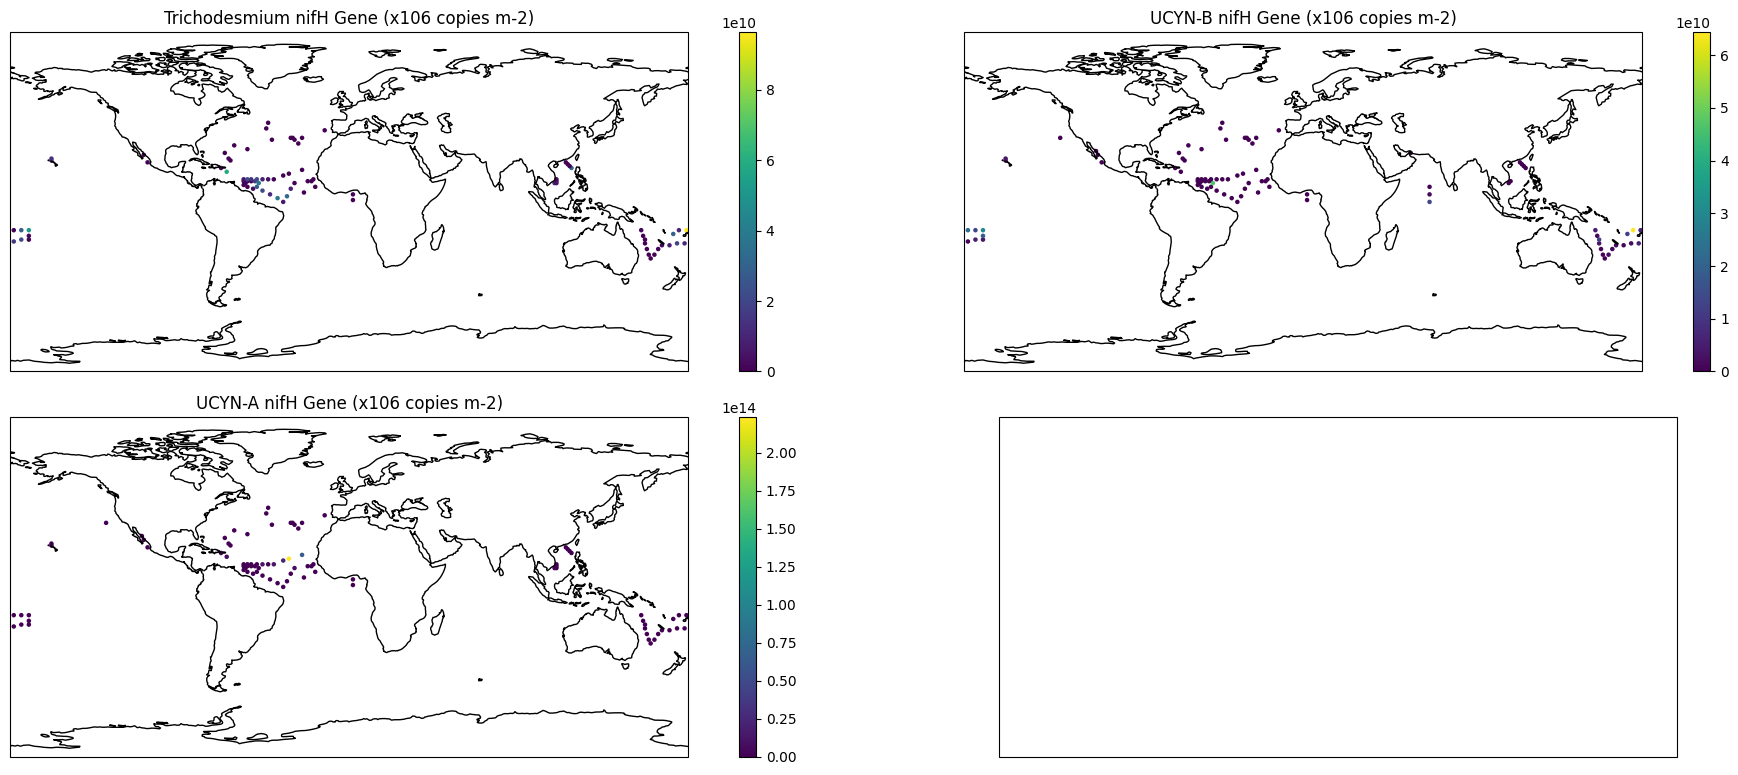

In [121]:
#the points in the dataset are plotted on the map
plotColsOnMap(maredat_cols,maredat_nifh_rnd)

In [122]:
maredat_nifh_rnd.describe()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-2),UCYN-B nifH Gene (x106 copies m-2),UCYN-A nifH Gene (x106 copies m-2)
count,109.000000,109.000000,103.000000,103.000000,1.040000e+02
mean,8.908257,-15.568807,8758.164291,3135.264437,3.390292e+06
std,17.731298,108.747786,15011.374541,9392.556052,2.281439e+07
min,-30.000000,-178.000000,0.000000,0.000000,0.000000e+00
25%,3.000000,-65.000000,88.615000,0.295000,4.700000e-01
50%,11.000000,-40.000000,1119.090000,44.330000,2.130100e+02
75%,23.000000,109.000000,11128.885000,1155.345000,7.760858e+03
max,42.000000,179.000000,96271.550000,64339.730000,2.231662e+08


In [123]:
maredat_nifh_rnd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   109 non-null    int64  
 1   LONGITUDE                                  109 non-null    int64  
 2   Trichodesmium nifH Gene (x106 copies m-2)  103 non-null    float64
 3   UCYN-B nifH Gene (x106 copies m-2)         103 non-null    float64
 4   UCYN-A nifH Gene (x106 copies m-2)         104 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 4.4 KB


# Third dataset

This is an additional dataset that is meant to contain more diverse data than the first 2. It is based on Tang [Data-Driven Modeling of the Distribution of Diazotrophs in the Global Ocean](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2019GL084376)

In [124]:
tang_nifh = pd.read_csv("../csv/nifh_di/Tang_GeophysicalResLett_2019_Data_depth_int.csv")
print(tang_nifh.info())
tang_nifh.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 42 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    21 non-null     object 
 1   METHODS:                  Sampling/Analysis                     263 non-null    object 
 2   DATE (yyyy-mm-dd)                                               263 non-null    object 
 3   LATITUDE                                                        263 non-null    float64
 4   LONGITUDE                                                       263 non-null    float64
 5   Integral DEPTH (m)                                              263 non-null    float64
 6   Trichodesmium nifH Gene (x106 copies m-2)                       223 non-null    object 
 7   Trichodesmium Biomass Conversion factor (mg C/106 nif

,SOURCE: Data,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,Integral DEPTH (m),Trichodesmium nifH Gene (x106 copies m-2),Trichodesmium Biomass Conversion factor (mg C/106 nifH copies),Trichodesmium Biomass (mg C m-2),UCYN-A1 nifH Gene (x106 copies m-2),...,CIII nifH Gene (x106 copies/m3),Total Diazotrophic Biomass (mg C m-2),Surface Temperature (˚C),Surface Salinity (PSU),Surface Nitrate (µM),Surface Phosphate (µM),N:P ratio,Surface Fe (nM),Chlorophyll (mg m-2),Notes
0,"Takuhei Shiozaki et al., 2014. Continetal Shel...",qPCR,2010 May,21.5,122.0,200.0,12000.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.02,0.03,NaN,NaN,NaN,NaN
1,NaN,qPCR,2010 May,21.5,122.5,200.0,16000.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.01,0.08,NaN,NaN,NaN,NaN
2,data shown in table 3,qPCR,2010 May,21.0,120.0,200.0,2100.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.01,0.03,NaN,NaN,NaN,NaN
3,NaN,qPCR,2010 May,21.0,119.5,200.0,1500.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.02,0.03,NaN,NaN,NaN,NaN
4,NaN,qPCR,2010 May,21.0,118.0,200.0,12000.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.01,0.04,NaN,NaN,NaN,NaN


In [125]:
tang_cols = ['Trichodesmium nifH Gene (x106 copies m-2)','UCYN-A nifH Gene (x106 copies m-2)','UCYN-B nifH Gene (x106 copies m-2)']

setND(tang_nifh, tang_cols)
#first step
removeRed(coord+tang_cols, tang_nifh)
objToNum(tang_nifh)

#second step
#tang_nifh_df = filterDepth(tang_nifh)
tang_nifh_df = tang_nifh.copy()
tang_nifh_df = removeEmptyRows(tang_cols,tang_nifh_df)


#coordinates are rounded
tang_nifh_rnd = roundCoord(tang_cols, tang_nifh_df)

tang_nifh_rnd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 262 entries, 0 to 262
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   262 non-null    int64  
 1   LONGITUDE                                  262 non-null    int64  
 2   Trichodesmium nifH Gene (x106 copies m-2)  223 non-null    float64
 3   UCYN-A nifH Gene (x106 copies m-2)         252 non-null    float64
 4   UCYN-B nifH Gene (x106 copies m-2)         226 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 12.3 KB


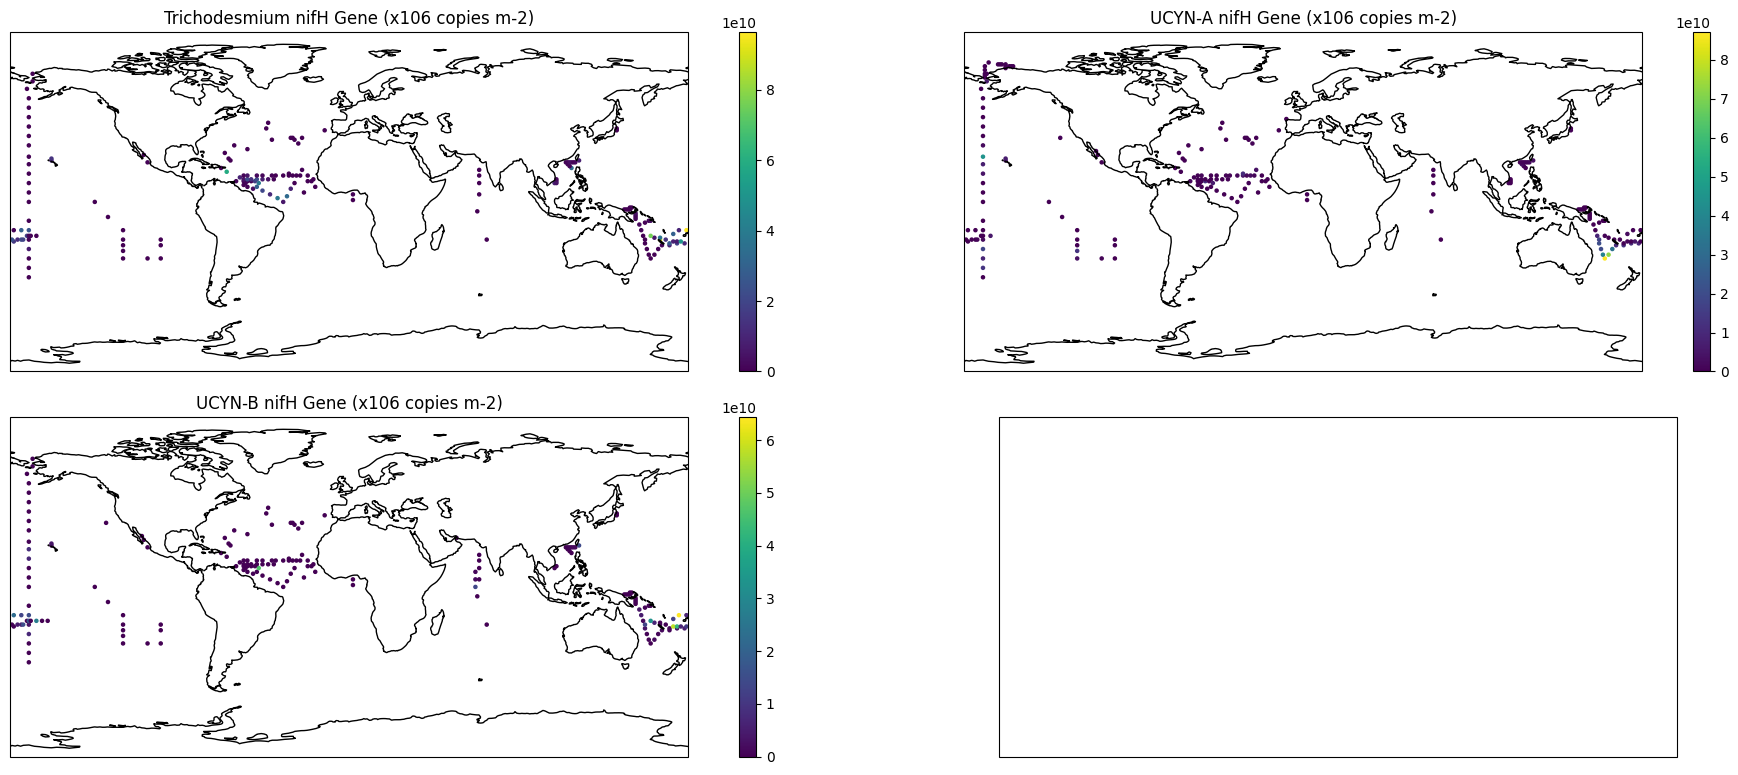

In [126]:

plotColsOnMap(tang_cols,tang_nifh_rnd)

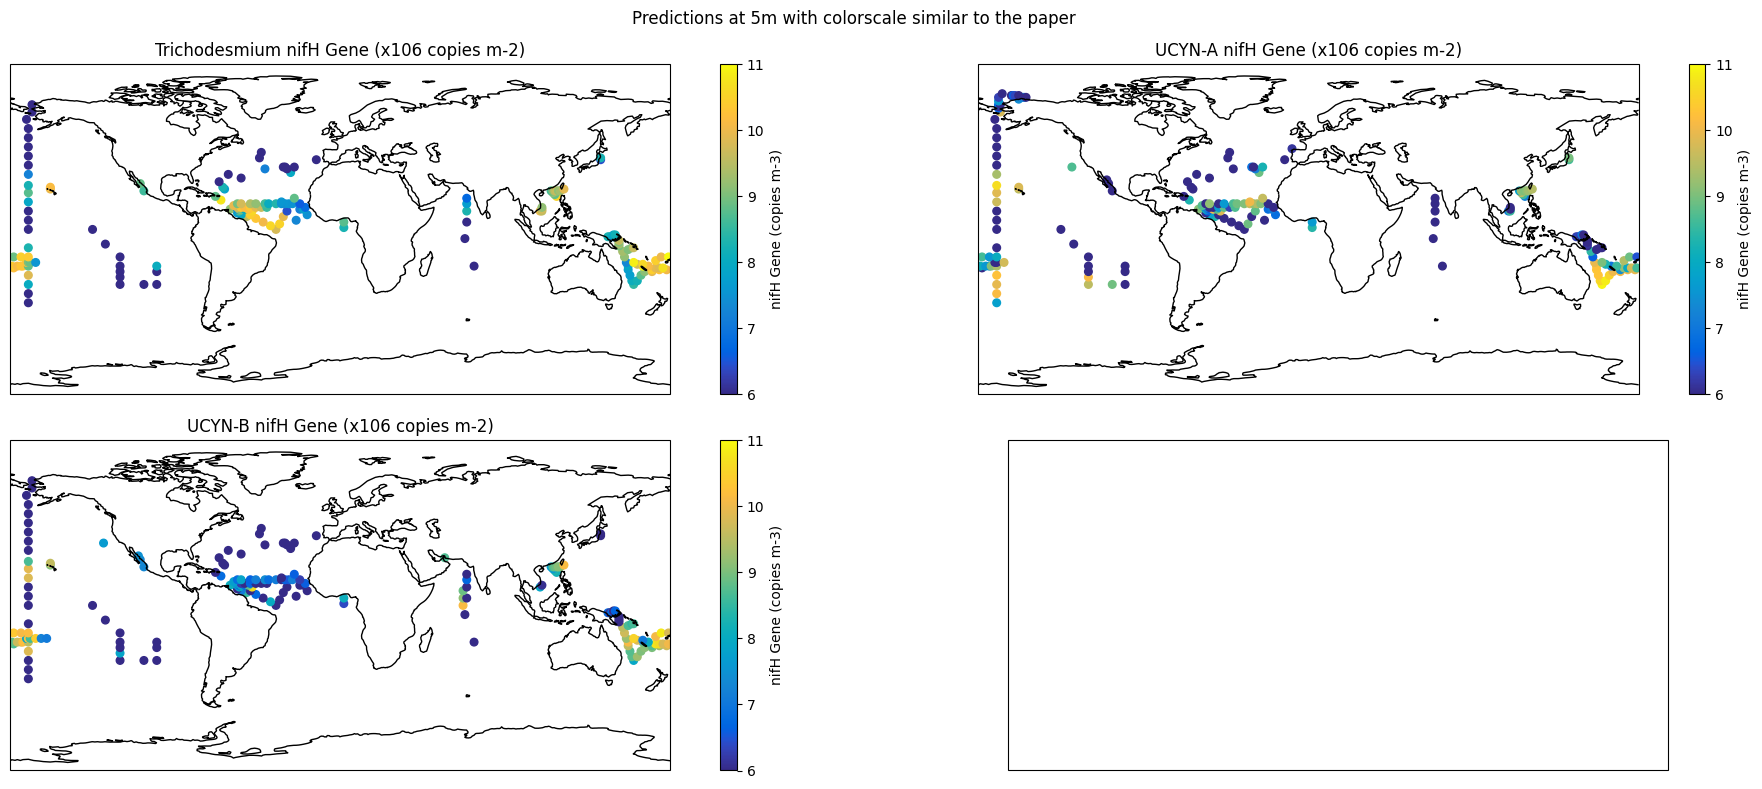

In [127]:


plotColsOnMap(
    tang_cols,tang_nifh_rnd,
    constant=(10**6), 
    transf=(lambda x: np.log10(x+10)),
    min_lim=6,
    max_lim=11,
    cmap=parula_map,
    colorbar_label="nifH Gene (copies m-3)",
    title="Predictions at 5m with colorscale similar to the paper",
    s=30
    )

In [128]:
tang_nifh_rnd.describe()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-2),UCYN-A nifH Gene (x106 copies m-2),UCYN-B nifH Gene (x106 copies m-2)
count,262.000000,262.000000,223.000000,252.000000,226.000000
mean,14.011450,-12.595420,6456.477094,2679.634978,2816.675429
std,26.973732,125.594115,13935.321022,8775.780448,8770.423575
min,-40.000000,-179.000000,0.000000,0.000000,0.000000
25%,-7.750000,-155.750000,20.790000,0.000000,0.000000
50%,14.000000,-32.500000,700.000000,21.910000,14.340000
75%,25.000000,118.000000,5733.310000,1300.000000,757.500000
max,74.000000,179.000000,96271.550000,87001.380000,64339.730000


In [129]:
tang_nifh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   263 non-null    float64
 1   LONGITUDE                                  263 non-null    float64
 2   Trichodesmium nifH Gene (x106 copies m-2)  223 non-null    float64
 3   UCYN-A nifH Gene (x106 copies m-2)         252 non-null    float64
 4   UCYN-B nifH Gene (x106 copies m-2)         226 non-null    float64
dtypes: float64(5)
memory usage: 10.4 KB


# Combining all of them together into 1
Since both datasets have been cleaned and prepared, we can finally try joining them together into a single table that we can later combine with environmental data and train the model.

The first step is to rename the column names that do not match and concatenate the 2 dataframes together into a single one.

In [134]:
#final data columns that we intend to keep
bact_cols=['Trichodesmium nifH Gene (x106 copies m-2)','UCYN-A nifH Gene (x106 copies m-2)','UCYN-B nifH Gene (x106 copies m-2)']


combined_df = pd.concat([dzdb_2024_nifh_rnd, maredat_nifh_rnd, tang_nifh_rnd])

combined_df.head()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-2),UCYN-A nifH Gene (x106 copies m-2),UCYN-B nifH Gene (x106 copies m-2)
0,23,-158,271.12,11028.19,208.90
1,23,-158,462.78,3678.99,33237.66
2,23,-158,4861.12,14646.35,5.77
3,23,-158,18000.00,6400.00,260.00
4,22,-158,17000.00,5800.00,2300.00


So far there is one of the coordinates which is a float instead of int, this can be fixed.

In [135]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1024 entries, 0 to 262
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   1024 non-null   int64  
 1   LONGITUDE                                  1024 non-null   int64  
 2   Trichodesmium nifH Gene (x106 copies m-2)  939 non-null    float64
 3   UCYN-A nifH Gene (x106 copies m-2)         908 non-null    float64
 4   UCYN-B nifH Gene (x106 copies m-2)         894 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 48.0 KB


In [136]:
#save the data
combined_df.to_csv("../csv/features/bact_data_di.csv", index=False)

After joining them together we want to plot the distributions in the resulting data.*bact_cols* list all columns that contain bacterial data, that we want to show.

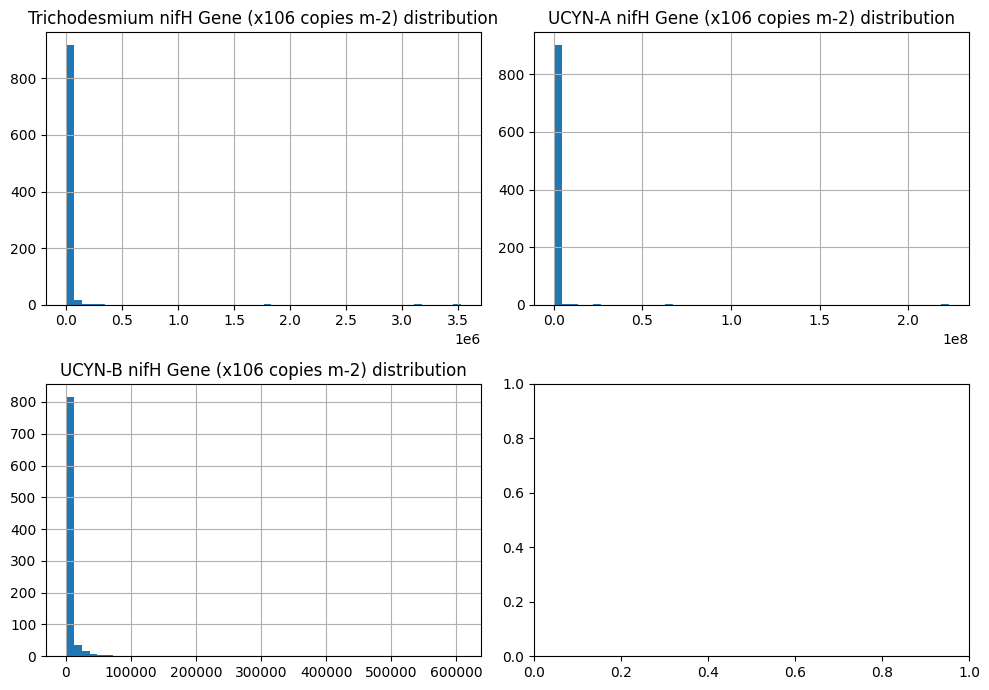

In [137]:
#I want to see the distributions of each variable to see what we are working with 
figure, axis = plt.subplots(2, 2, figsize = (10,7))

#i want to see distributions of the points
axes = axis.flatten()
for i, bact in enumerate(bact_cols):
    title = bact+" distribution"
    ax = axes[i]
    
    combined_df[bact].hist(bins=50,ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

We know from plotting data on a map and the initial plots in the paper, that the authors multiplied it by $10^6$ and plotted on a logarithmic scale. So, I wanted to try multiplication and then taking the logorithm to see the possible results.

0.0
0.0
0.0


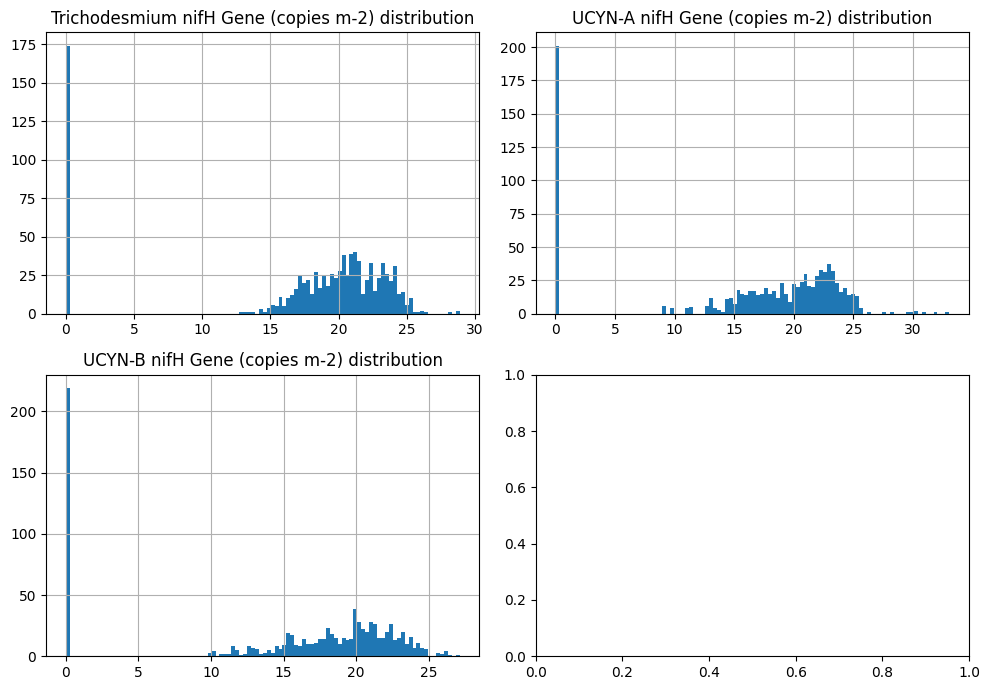

In [138]:
#another plot, but here the data is modified
figure, axis = plt.subplots(2, 2, figsize = (10,7))

#i want to see distributions of the points when we modify it
axes = axis.flatten()
for i, bact in enumerate(bact_cols):
    title = bact+" distribution"
    ax = axes[i]

    mod_ar = np.log(combined_df[bact]*(10**6)+1)
    print(mod_ar.min())
    
    mod_ar.hist(bins=100,ax=ax)
    ax.set_title(title.replace("x106 ",""))

plt.tight_layout()
plt.show()

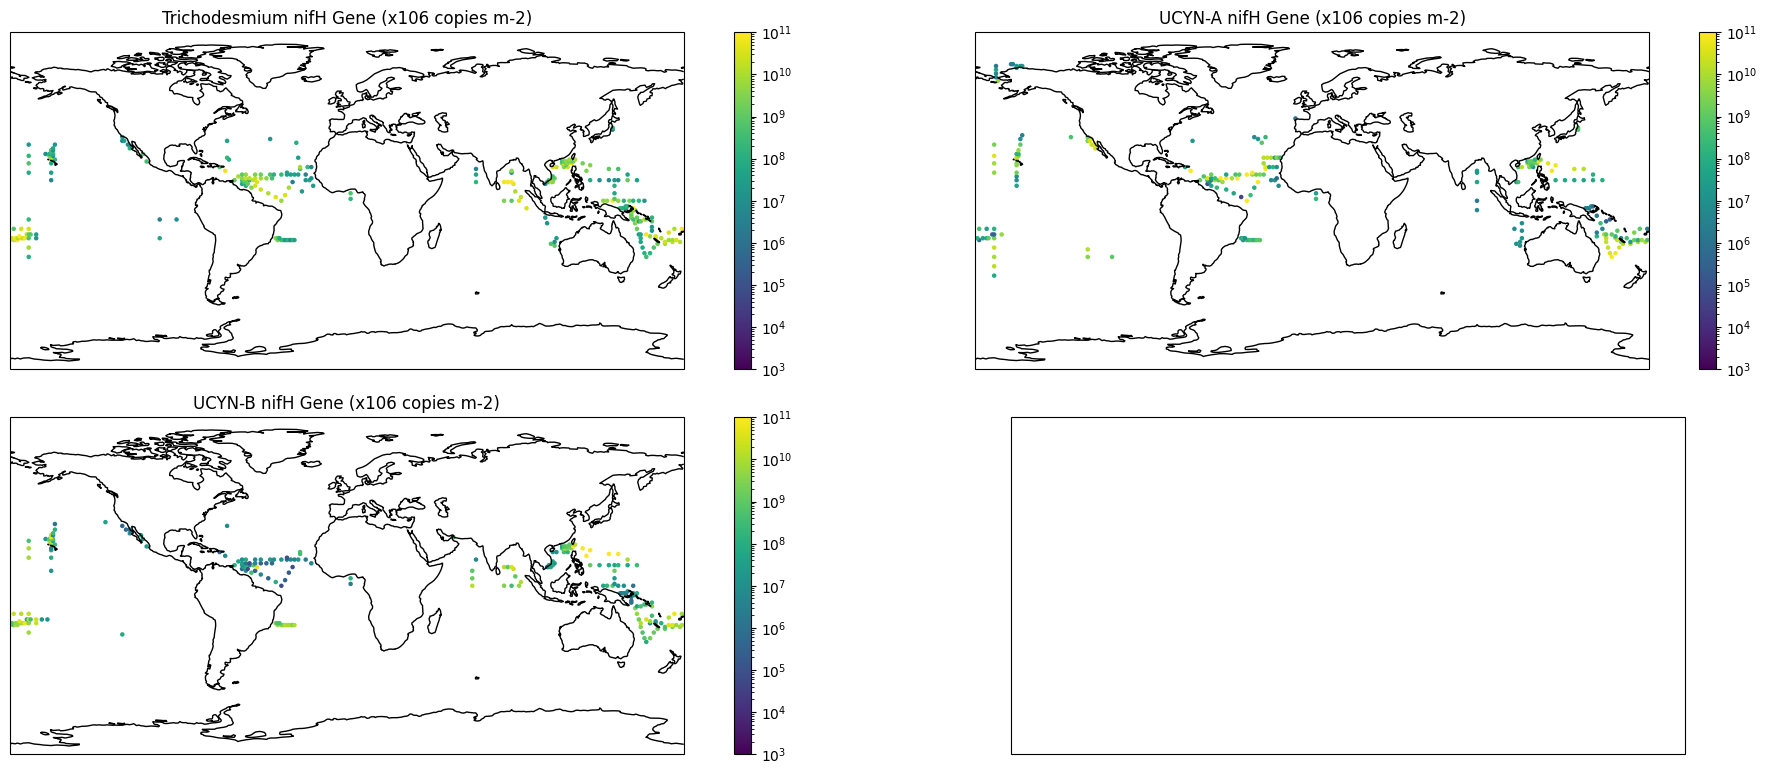

In [139]:
plotColsOnMap(bact_cols, combined_df,True)

In [140]:
combined_df.describe()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-2),UCYN-A nifH Gene (x106 copies m-2),UCYN-B nifH Gene (x106 copies m-2)
count,1024.000000,1024.000000,9.390000e+02,9.080000e+02,894.000000
mean,13.121094,-26.938477,1.634376e+04,3.949588e+05,5893.526805
std,22.601330,125.342569,1.650295e+05,7.763400e+06,30240.458930
min,-40.000000,-180.000000,0.000000e+00,0.000000e+00,0.000000
25%,0.000000,-158.000000,1.868000e+01,4.100000e-01,0.030000
50%,17.000000,-46.000000,4.603100e+02,1.613000e+02,74.320000
75%,23.000000,112.000000,4.451930e+03,5.151597e+03,1500.000000
max,74.000000,179.000000,3.525556e+06,2.231662e+08,607258.350000
